In [1]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import(mean_absolute_error, mean_squared_error)

Load Clean Dataset

In [3]:
df = pd.read_csv("../data/processed/cleaned_metal_prices.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

df.head()

,Year,Month,Price_alum,Price_gold,Price_nickel,Price_silver,Price_uran,Inflation_rate,Price_alum_infl,Price_gold_infl,Price_nickel_infl,Price_silver_infl,Price_uran_infl
Date,,,,,,,,,,,,,
1992-02-01,1992,Feb,1266.83,353.91,7861.9,4.15,7.90,89.59,2401.782997,670.977969,14905.37621,7.867985,14.977610
1992-03-01,1992,Mar,1280.47,344.34,7417.7,4.11,7.75,89.59,2427.643073,652.834206,14063.21743,7.792149,14.693225
1992-04-01,1992,Apr,1317.05,338.62,7420.6,4.05,7.75,89.59,2496.995095,641.989658,14068.71554,7.678395,14.693225
1992-05-01,1992,May,1306.79,337.24,7326.8,4.07,7.55,89.59,2477.543161,639.373316,13890.88012,7.716313,14.314045
1992-06-01,1992,Jun,1275.55,340.81,7192.8,4.06,7.75,89.59,2418.315245,646.141679,13636.82952,7.697354,14.693225


In [4]:
gold = df["Price_gold"]

Visualize time series

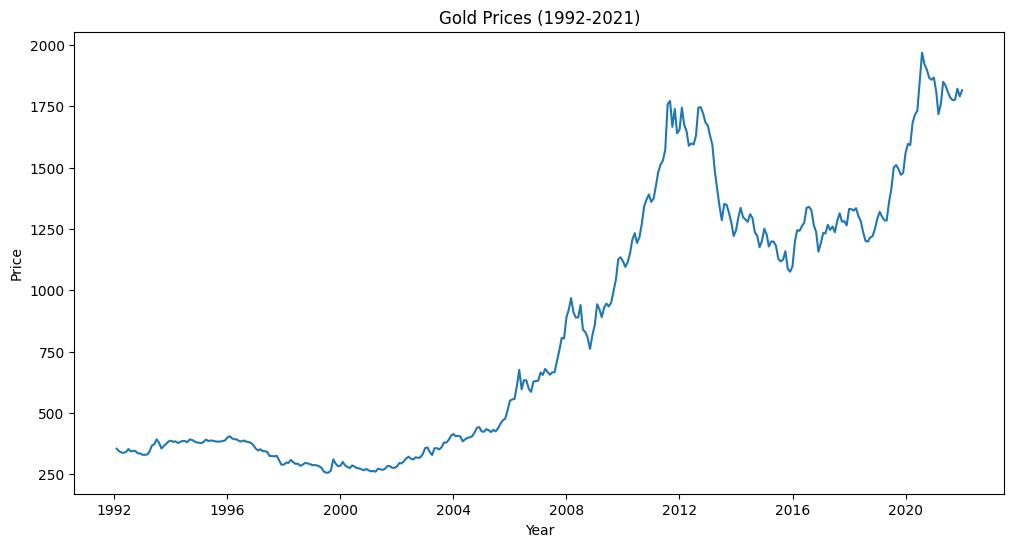

In [5]:
plt.figure(figsize=(12,6))
plt.plot(gold)
plt.title("Gold Prices (1992-2021)")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

Train-Test split

In [6]:
train_size = int(len(gold) * 0.8)

train = gold[:train_size]

test = gold[train_size:]

ARIMA MODEL

In [7]:
model = ARIMA(train, order=(5,1,0)) # p,d,q values can be tuned for better performance
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Price_gold   No. Observations:                  288
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1393.243
Date:                Tue, 02 Jun 2026   AIC                           2798.485
Time:                        21:34:22   BIC                           2820.442
Sample:                    02-01-1992   HQIC                          2807.285
                         - 01-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1733      0.045      3.881      0.000       0.086       0.261
ar.L2         -0.0677      0.034     -2.017      0.044      -0.133      -0.002
ar.L3          0.0924      0.042      2.183      0.0

C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Forecast -
predicting for test period

In [8]:
forecast = model_fit.forecast(steps=len(test))


Evaluate

MAE

In [9]:
mae = mean_absolute_error(test, forecast)
print("MAE:", mae)

MAE: 374.56153808686224


RMSE

In [10]:
rmse = np.sqrt(mean_squared_error(test,forecast))
print("RMSE:", rmse)

RMSE: 450.2389833975868


Visualization

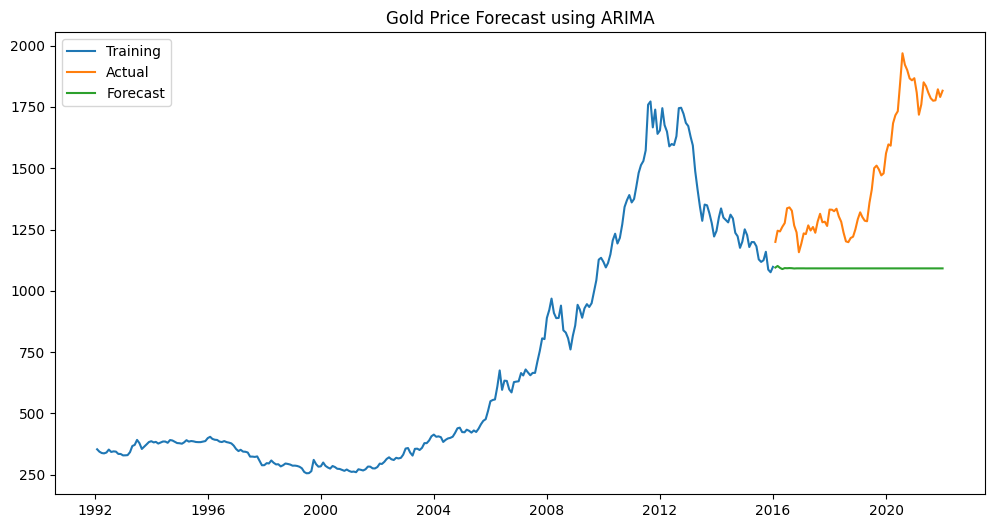

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train,
    label="Training"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    forecast,
    label="Forecast"
)

plt.title(
    "Gold Price Forecast using ARIMA"
)

plt.legend()

plt.show()

In [13]:
final_model = ARIMA(gold, order=(5,1,0))

final_fit = final_model.fit()

C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [14]:
future_forecast = final_fit.forecast(steps=12)

print(future_forecast)

2022-02-01    1825.057454
2022-03-01    1822.081649
2022-04-01    1829.430304
2022-05-01    1826.553045
2022-06-01    1828.417814
2022-07-01    1830.803311
2022-08-01    1830.366169
2022-09-01    1831.305920
2022-10-01    1831.214446
2022-11-01    1831.273596
2022-12-01    1831.689902
2023-01-01    1831.679516
Freq: MS, Name: predicted_mean, dtype: float64
